<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB21 · Python de verdad (2): colecciones

**Parte 3 · Python de verdad — Lección 2**

> En el **NB20** aprendiste a manejar texto como un profesional. Hoy toca la otra herramienta de todos los días: las
> **colecciones**, es decir, las formas de guardar **muchos datos juntos**.

Ya conoces una colección: la **lista** (NB09). Hoy la estudiaremos a fondo (con una trampa famosísima que **tienes** que conocer
para no perder horas buscando un error), y conocerás tres más:

- La **tupla**: una lista que no se puede cambiar.
- El **diccionario**: datos con **nombre**, la estructura de todas las configuraciones.
- El **conjunto**: una colección sin repetidos.

Y al final, juntaremos todo para guardar la **configuración completa de un entrenamiento** y hacer un **ranking** de políticas, como en un
proyecto de verdad.


## 1 · Tuplas: listas que no cambian

Una **tupla** es como una lista, pero se escribe con **paréntesis** en vez de corchetes, y, como las cadenas (NB20), es **inmutable**: una vez
creada, no se puede cambiar. Ya la viste de pasada en el NB15: la **forma** de un array, `(17, 348)`, es una tupla.


In [1]:
posicion_pie = (0.25, -0.10, 0.0)      # x, y, z en metros
print(posicion_pie)
print(posicion_pie[0])
print(len(posicion_pie))

(0.25, -0.1, 0.0)
0.25
3


Índices y `len`, como en una lista. Pero si intentas cambiarla:

In [2]:
posicion_pie[2] = 0.5

TypeError: 'tuple' object does not support item assignment

`TypeError: 'tuple' object does not support item assignment`, el mismo error que con las cadenas. **¿Para qué quiero algo que no puedo
cambiar?** Para datos que **forman un todo fijo** y que no deberían modificarse por accidente: una posición (x, y, z), un color (rojo, verde,
azul), el tamaño de una matriz (filas, columnas). Si alguien intenta cambiarlos sin querer, Python lo impide. Es una **protección**.

(Un detalle curioso: una tupla de **un solo** elemento se escribe con una coma, `(5,)`, porque `(5)` sería simplemente el número 5 entre
paréntesis. Por eso la forma de un vector en NumPy sale como `(348,)`, NB15.)


### Desempaquetar

La tupla tiene un truco precioso, que ya has usado sin saber su nombre. Si a la izquierda del `=` pones **varias cajas** separadas por comas, Python
**reparte** los elementos de la tupla entre ellas. Se llama **desempaquetar**:


In [3]:
x, y, z = posicion_pie
print("x =", x, "| y =", y, "| z =", z)

x = 0.25 | y = -0.1 | z = 0.0


Cada caja se lleva un elemento, por orden. (El número de cajas tiene que coincidir con el de elementos; si no, `ValueError`.)

¿Y te acuerdas de las funciones que devolvían dos valores, como `return altura, velocidad` en el NB10? **Estaban devolviendo una tupla**. Y
`altura, velocidad = paso_pelota(...)` la estaba **desempaquetando**. Lo mismo que `observacion, info = entorno.reset()` en el NB15. Ahora sabes qué
pasaba por debajo:


In [4]:
def reiniciar():
    return 2.0, 0.0

resultado = reiniciar()
print(resultado, type(resultado))

(2.0, 0.0) <class 'tuple'>


`(2.0, 0.0)`, de tipo `tuple`. La coma en el `return` fabrica una tupla.

Y un truco elegantísimo que sale de aquí: **intercambiar** el contenido de dos cajas en una sola línea (en otros lenguajes hace falta una caja
auxiliar):


In [5]:
a, b = 1, 2
a, b = b, a
print(a, b)

2 1


## 2 · Listas a fondo

Las listas tienen muchos más métodos que el `append` del NB09. Vamos con los importantes, sobre una lista de retornos:

In [6]:
retornos = [44.8, 213.5, 97.2, 455.3]

retornos.insert(1, 120.0)      # mete 120.0 en la posición 1 (desplaza el resto)
print(retornos)

ultimo = retornos.pop()        # saca el ÚLTIMO y lo devuelve
print("sacado:", ultimo, "| quedan:", retornos)

retornos.remove(213.5)         # quita el primer elemento que valga 213.5
print(retornos)

[44.8, 120.0, 213.5, 97.2, 455.3]
sacado: 455.3 | quedan: [44.8, 120.0, 213.5, 97.2]
[44.8, 120.0, 97.2]


- **`insert(posición, valor)`** mete un elemento donde digas.
- **`pop()`** saca el último **y te lo da** (muy útil para ir "gastando" una lista). Con un índice, `pop(0)`, saca ese.
- **`remove(valor)`** quita el primer elemento con ese valor (si no existe, `ValueError`).

Unos cuantos más:


In [7]:
print(retornos.index(97.2))         # ¿en qué posición está?
retornos.extend([300.0, 499.9])     # añade VARIOS al final (append añadiría la lista entera como un elemento)
print(retornos)
del retornos[0]                     # borra por posición
print(retornos)

2
[44.8, 120.0, 97.2, 300.0, 499.9]
[120.0, 97.2, 300.0, 499.9]


### Ordenar: `sort` contra `sorted`

Hay **dos** formas de ordenar, y conviene no confundirlas:

- **`lista.sort()`** ordena **la propia lista**, cambiándola, y **no devuelve nada** (`None`, NB10).
- **`sorted(lista)`** **no toca** la lista: devuelve una lista **nueva**, ordenada.


In [8]:
numeros = [3, 1, 2]
nueva = sorted(numeros)
print("sorted:", nueva, "| la original sigue:", numeros)

numeros.sort()
print("después de sort:", numeros)

print("de mayor a menor:", sorted(numeros, reverse=True))

sorted: [1, 2, 3] | la original sigue: [3, 1, 2]
después de sort: [1, 2, 3]
de mayor a menor: [3, 2, 1]


Un error clásico es escribir `numeros = numeros.sort()`: como `sort` devuelve `None`, ¡te quedas con `None` y pierdes la lista! Regla: **`sort`
cambia y no devuelve; `sorted` devuelve y no cambia.** (`reverse=True` ordena de mayor a menor.)


### Porciones con salto

Las porciones (NB09) admiten un **tercer número**, el **salto**, igual que `range` (NB07): `lista[inicio:fin:salto]`:

In [9]:
pasos = list(range(10))
print(pasos)
print(pasos[::2])       # de 2 en 2: todos los pares
print(pasos[::-1])      # salto -1: ¡al revés!

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[0, 2, 4, 6, 8]
[9, 8, 7, 6, 5, 4, 3, 2, 1, 0]


(`list(range(10))` convierte el recorrido de `range` en una lista de verdad, para poder verla.) `[::-1]` es el truco más usado para **dar la vuelta**
a una lista (o a una cadena: `"hola"[::-1]` da `"aloh"`). Y `[::2]` sirve, por ejemplo, para quedarte con una de cada dos fotos de una trayectoria.


## 3 · La trampa del alias (importantísimo)

Esta es una de las fuentes de errores más famosas de Python. Lee esto con calma, porque **te va a pasar**.

Mira este código. Creamos una lista, hacemos una "copia" con `=`, y cambiamos la copia:


In [10]:
original = [1, 2, 3]
copia = original
copia.append(4)

print("copia:   ", copia)
print("original:", original)

copia:    [1, 2, 3, 4]
original: [1, 2, 3, 4]


¡¿La **original** también tiene el 4?! No hemos tocado `original`... ¿o sí?

Lo que pasa es que `copia = original` **no copia la lista**. Lo que hace es pegarle **una segunda etiqueta** a **la misma caja**. Hay **una sola lista**,
con dos nombres:

```
   copia = original

   original ──┐
              ├──►  [1, 2, 3]      ← UNA sola lista, con dos etiquetas
   copia ─────┘

   copia.append(4) cambia ESA lista... y se ve desde las dos etiquetas.
```

Cuando dos nombres apuntan al mismo objeto, se dice que uno es un **alias** del otro. Con las cajas de números del NB06 no se notaba, porque los números
(como las cadenas y las tuplas) son inmutables: "cambiarlos" siempre crea uno nuevo. Pero las listas (y los diccionarios, y los arrays de NumPy) se pueden
**cambiar por dentro**, y entonces el alias muerde.

**¿Cómo se hace una copia de verdad?** Con el método **`copy()`** (que ya usaste con un array en el NB18), o con `list(...)`, o con la porción completa `[:]`:


In [11]:
original = [1, 2, 3]
copia = original.copy()
copia.append(4)

print("copia:   ", copia)
print("original:", original)

copia:    [1, 2, 3, 4]
original: [1, 2, 3]


Ahora sí: dos listas **independientes**. Para comprobar si dos nombres son **el mismo objeto** (no solo "iguales por dentro"), existe la palabra **`is`**:

In [12]:
a = [1, 2, 3]
b = a
c = a.copy()
print("a == c:", a == c, "(iguales por dentro)")
print("a is b:", a is b, "(el mismo objeto)")
print("a is c:", a is c, "(objetos distintos)")

a == c: True (iguales por dentro)
a is b: True (el mismo objeto)
a is c: False (objetos distintos)


**Dónde te morderá en robótica:** guardas el estado de un robot en una lista, la añades al historial de la trayectoria (NB09), y luego **modificas el
estado** para el siguiente paso... y todo el historial cambia a la vez, porque guardaste muchas veces **la misma** lista. La solución: guardar una **copia**
cada vez (`historial.append(estado.copy())`).

(Un último matiz, para más adelante: `copy()` hace una **copia superficial**. Si la lista contiene **otras listas** dentro (como una matriz, NB14), la copia
tiene sus propias "filas"... que siguen siendo las mismas listas de dentro. Para copiarlo todo, hasta el fondo, existe `copy.deepcopy`, del módulo `copy`.)


## 4 · Recorrer con número: `enumerate`

Muchas veces, al recorrer una lista, necesitas **el elemento y su posición**. Podrías usar `range(len(...))` (NB09), pero hay una forma más limpia:
**`enumerate`**, que en cada vuelta te da **una tupla** (posición, elemento), que se desempaqueta en el propio `for`:


In [13]:
motores = ["cadera", "rodilla", "tobillo"]
for i, motor in enumerate(motores):
    print(i, motor)

0 cadera
1 rodilla
2 tobillo


## 5 · Recorrer dos listas a la vez: `zip`

Y para recorrer **dos listas emparejadas** (las listas paralelas del NB09), **`zip`** ("cremallera"): junta los elementos de las dos listas por parejas,
como los dientes de una cremallera:


In [14]:
valores = [0.3, -0.4, 0.1]
for motor, valor in zip(motores, valores):
    print(f"{motor:>8}: {valor:+.1f}")

  cadera: +0.3
 rodilla: -0.4
 tobillo: +0.1


Mucho más legible que `for i in range(len(motores)): print(motores[i], valores[i])`. **`enumerate` y `zip` son de las herramientas más usadas de Python**;
cuando veas `range(len(...))` en un código, casi siempre se puede escribir mejor con una de las dos.


## 6 · Comprensiones de listas

En el NB14 viste de pasada una forma corta de fabricar listas: `[round(a, 2) for a in acciones]`. Se llama **comprensión de listas** y es una de las cosas
más "pythónicas" que existen (es decir, muy del estilo de Python). Es una forma de escribir en **una línea** este patrón tan común:

```
   resultado = []                          resultado = [x ** 2 for x in numeros]
   for x in numeros:              =
       resultado.append(x ** 2)
```

Se lee casi en castellano: "**x al cuadrado, para cada x en números**".


In [15]:
numeros = [1, 2, 3, 4, 5]
cuadrados = [x ** 2 for x in numeros]
print(cuadrados)

[1, 4, 9, 16, 25]


Y admite un **filtro** con `if` al final: solo entran los elementos que cumplen la condición. Por ejemplo, quedarse solo con los retornos de los
episodios **completos** (más de 400 puntos), redondeados:


In [16]:
retornos = [44.8, 97.23, 213.5, 455.31, 499.94]
buenos = [round(r) for r in retornos if r > 400]
print(buenos)

[455, 500]


"El retorno redondeado, para cada retorno, **si** es mayor que 400". Úsalas cuando la lista se pueda describir en una frase corta; si la lógica es
complicada, un bucle normal es más claro. **La claridad siempre gana a la brevedad.**


## 7 · Diccionarios: datos con nombre

Imagina que quieres guardar la **ficha** de un robot: su nombre, su número de motores, su masa, si tiene tobillos... Con una lista tendrías que acordarte
de que "la posición 0 es el nombre, la 1 los motores, la 2 la masa"... un desastre.

Un **diccionario** guarda los datos con **nombre**: cada valor va asociado a una **clave**. Como un diccionario de papel, donde cada palabra (la clave)
tiene su definición (el valor). Se escribe con **llaves** `{ }`, con parejas `clave: valor` separadas por comas:


In [17]:
robot = {
    "nombre": "Humanoid-v5",
    "motores": 17,
    "masa_kg": 40.0,
    "tiene_tobillos": False,
}
print(robot)

{'nombre': 'Humanoid-v5', 'motores': 17, 'masa_kg': 40.0, 'tiene_tobillos': False}


Para sacar un valor, se usa su **clave** entre corchetes (en vez de una posición):

In [18]:
print(robot["nombre"])
print(robot["motores"])

Humanoid-v5
17


Mucho más legible que `robot[1]`: el código **dice** lo que hace. ¿Y si pides una clave que no existe?

In [19]:
print(robot["altura"])

KeyError: 'altura'

`KeyError: 'altura'`: "**error de clave**: no existe la clave `'altura'`". Otro tipo de error para la colección, el primo del `IndexError` de las listas.

Para evitarlo, existe el método **`get`**, que devuelve `None` (o el valor que le digas) si la clave no está, en vez de dar error:


In [20]:
print(robot.get("altura"))
print(robot.get("altura", 1.4))

None
1.4


### Añadir, cambiar, borrar y preguntar

Los diccionarios se pueden cambiar (como las listas: ¡cuidado con los alias del apartado 3!). Guardar con una clave **nueva** la **añade**; con una clave
que ya existe, **cambia** su valor:


In [21]:
robot["altura"] = 1.4          # clave nueva: se añade
robot["masa_kg"] = 41.5        # clave existente: se cambia
del robot["tiene_tobillos"]    # se borra
print(robot)
print("¿Tiene 'motores'?", "motores" in robot)
print("Número de claves:", len(robot))

{'nombre': 'Humanoid-v5', 'motores': 17, 'masa_kg': 41.5, 'altura': 1.4}
¿Tiene 'motores'? True
Número de claves: 4


`in` pregunta si existe una **clave** (no un valor).

### Recorrer un diccionario

Hay tres formas, según lo que quieras: las **claves** (`keys`), los **valores** (`values`) o las **parejas** (`items`, que da tuplas para desempaquetar):


In [22]:
for clave, valor in robot.items():
    print(f"{clave:>8}: {valor}")

  nombre: Humanoid-v5
 motores: 17
 masa_kg: 41.5
  altura: 1.4


`.items()` es, con diferencia, la más usada. (Desde hace años, los diccionarios de Python **recuerdan el orden** en que se añadieron las claves.)

### ¿Dónde están los diccionarios en robótica? En todas partes

- El `info` que devuelve `entorno.step(...)` en Gymnasium (NB15) **es un diccionario**, con datos extra sobre el paso.
- Las **configuraciones** de un entrenamiento (tasa de aprendizaje, número de pasos, tamaño de la red...) se guardan en diccionarios.
- Los **resultados** de un experimento ("retorno medio": 455,3; "episodios": 50...).
- Las redes de PyTorch guardan sus pesos en un diccionario (lo verás).

Miremos el `info` de verdad del humanoide:


In [23]:
import gymnasium as gym
import numpy as np

entorno = gym.make("Humanoid-v5")
observacion, info = entorno.reset(seed=0)
observacion, recompensa, terminado, truncado, info = entorno.step(np.zeros(17))
entorno.close()

print(type(info))
for clave, valor in info.items():
    if isinstance(valor, float):
        print(f"{clave:>16}: {valor:.4f}")

<class 'dict'>
      x_position: 0.0027
      y_position: -0.0046
distance_from_origin: 0.0054
      x_velocity: 0.0019
      y_velocity: -0.0000
  reward_survive: 5.0000
  reward_forward: 0.0024
     reward_ctrl: -0.0000
  reward_contact: -0.0000


¡Un diccionario! Y entre sus claves están los **ingredientes de la recompensa** del NB04, por separado: `reward_survive` (el +5 por seguir de pie),
`reward_forward` (el premio por avanzar), `reward_ctrl` (el castigo por esfuerzo) y `reward_contact` (el de los golpes). Sumados, dan la recompensa del
paso. (`isinstance(valor, float)` pregunta "¿es `valor` un número decimal?"; lo usamos para mostrar solo los números y saltarnos datos más complejos.)

Con esto, un ingeniero puede **vigilar cada ingrediente por separado** durante el entrenamiento, y detectar trampas como las del NB04 (por ejemplo, ver que
casi todos los puntos vienen de `reward_survive` y casi nada de `reward_forward`: ¡el robot se está quedando quieto!).


### Diccionarios dentro de diccionarios

Los valores de un diccionario pueden ser **cualquier cosa**: listas, otros diccionarios... Así se construyen estructuras complejas, como la configuración
completa de un entrenamiento:


In [24]:
configuracion = {
    "entorno": "Humanoid-v5",
    "semillas": [0, 1, 2, 3, 4],
    "red": {"capas_ocultas": [256, 256], "activacion": "relu"},
    "entrenamiento": {"tasa": 0.0003, "pasos_totales": 10_000_000},
}

print(configuracion["red"]["capas_ocultas"])
print(configuracion["entrenamiento"]["tasa"])
print(len(configuracion["semillas"]), "semillas")

[256, 256]
0.0003
5 semillas


Para llegar a un dato "profundo", se encadenan las claves: `configuracion["red"]["capas_ocultas"]` es "de la configuración, la red; y de la red, las capas
ocultas". Esta estructura es **exactamente** la de los ficheros de configuración que se usan en los proyectos de verdad (en el NB26 aprenderemos a guardarla
en un fichero y a cargarla).


### Contar con un diccionario

Un uso clásico: **contar** cuántas veces aparece cada cosa. La clave es la cosa; el valor, cuántas veces la hemos visto. Por ejemplo, ¿por qué terminaron
estos episodios?


In [25]:
finales = ["caída", "tiempo", "caída", "caída", "tiempo", "caída"]

conteo = {}
for final in finales:
    conteo[final] = conteo.get(final, 0) + 1
print(conteo)

{'caída': 4, 'tiempo': 2}


El truco está en `conteo.get(final, 0) + 1`: "lo que hubiera contado hasta ahora (o 0 si es la primera vez), más 1". Es tan común que Python trae una
herramienta hecha, `Counter`, en el módulo `collections` (la veremos en el NB26).

Y como las listas, los diccionarios tienen su **comprensión**, con llaves y `clave: valor`:


In [26]:
pesos_capa = {f"capa_{i}": 256 // (2 ** i) for i in range(3)}
print(pesos_capa)

{'capa_0': 256, 'capa_1': 128, 'capa_2': 64}


(`//` es la **división entera**: divide y se queda solo con la parte entera, sin decimales. `256 // 4` da 64. Y su compañero, `%`, da el **resto**:
`7 % 2` es 1. Los dos son muy útiles; por ejemplo, `paso % 100 == 0` es `True` cada 100 pasos, el truco para mostrar un mensaje "de vez en cuando".)


## 8 · Conjuntos: sin repetidos

Un **conjunto** (*set*) es una colección **sin orden y sin repetidos**. Se escribe con llaves, pero sin el `clave:`. Su superpoder: si metes algo dos veces,
solo queda una:


In [27]:
entornos_probados = ["Hopper", "Walker2d", "Hopper", "Humanoid", "Walker2d"]
distintos = set(entornos_probados)
print(distintos)
print(len(distintos), "entornos distintos")

{'Hopper', 'Walker2d', 'Humanoid'}
3 entornos distintos


(El orden en que se muestran puede variar: los conjuntos **no guardan orden**.) Convertir una lista en conjunto es la forma más rápida de **quitar
repetidos**.

Y permiten las operaciones de los conjuntos de las matemáticas: **unión** (`|`, lo que está en cualquiera), **intersección** (`&`, lo que está en los dos) y
**diferencia** (`-`, lo que está en uno pero no en el otro):


In [28]:
yo = {"Hopper", "Walker2d", "Humanoid"}
companero = {"Walker2d", "Ant", "Humanoid"}

print("Probados por los dos:  ", sorted(yo & companero))
print("Probados por alguno:   ", sorted(yo | companero))
print("Solo yo:               ", sorted(yo - companero))

Probados por los dos:   ['Humanoid', 'Walker2d']
Probados por alguno:    ['Ant', 'Hopper', 'Humanoid', 'Walker2d']
Solo yo:                ['Hopper']


(Usamos `sorted` para mostrarlos siempre en el mismo orden, alfabético.) Además, preguntar si algo está en un conjunto (`in`) es **rapidísimo**, mucho más que
en una lista larga, porque el conjunto no tiene que recorrer todos sus elementos para saberlo.


## 9 · Preguntas a toda una colección: `any`, `all` y ordenar por una clave

**`any`** responde "¿**alguno** es verdadero?" y **`all`**, "¿**todos** son verdaderos?". Combinados con una comprensión, son muy expresivos:

In [29]:
pasos_por_episodio = [500, 500, 231, 500, 500]
print("¿Alguno se cayó?   ", any(p < 500 for p in pasos_por_episodio))
print("¿Todos completaron?", all(p == 500 for p in pasos_por_episodio))

¿Alguno se cayó?    True
¿Todos completaron? False


(Fíjate: aquí la comprensión va **sin corchetes**, directamente dentro de `any`. Es una variante que no fabrica la lista entera; lo explicaremos en el NB23,
con los generadores.)

### Ordenar por lo que tú digas: `key`

`sorted`, `max` y `min` aceptan un parámetro **`key`**: una **función** que dice, para cada elemento, **por qué valor** hay que ordenar (o comparar). Por ejemplo,
para ordenar parejas (nombre, retorno) **por el retorno**:


In [30]:
politicas = [("nada", 44.8), ("a mano", 499.9), ("azar", 43.2), ("solo inclinación", 296.0)]

def su_retorno(pareja):
    return pareja[1]

for nombre, retorno in sorted(politicas, key=su_retorno, reverse=True):
    print(f"{nombre:>17}: {retorno:6.1f}")

print("La mejor:", max(politicas, key=su_retorno))

           a mano:  499.9
 solo inclinación:  296.0
             nada:   44.8
             azar:   43.2
La mejor: ('a mano', 499.9)


`key=su_retorno` le dice a `sorted`: "para comparar dos parejas, mira lo que devuelve `su_retorno` de cada una" (fíjate: pasamos la **función** por su nombre,
sin paréntesis, como en el NB10). En el NB23 verás una forma más corta de escribir esas funciones de usar y tirar, las `lambda`.


## 10 · Proyecto: el cuaderno de experimentos

Juntemos todo en algo muy real. Un ingeniero prueba varias políticas en el palo de escoba y apunta los resultados. Cada experimento es un **diccionario** (con nombre,
ruedecillas y retornos de 5 semillas), y todos juntos, una **lista de diccionarios** (la estructura más común del mundo para guardar datos):


In [31]:
experimentos = [
    {"nombre": "nada",             "ruedecillas": (0, 0),  "retornos": [41.6, 46.2, 43.1, 45.3, 47.6]},
    {"nombre": "solo inclinación", "ruedecillas": (30, 0), "retornos": [499.7, 168.5, 144.5, 198.8, 468.3]},
    {"nombre": "a mano",           "ruedecillas": (30, 8), "retornos": [499.9, 499.9, 499.9, 499.9, 499.9]},
    {"nombre": "aprendida",        "ruedecillas": (47.9, 6.7), "retornos": [499.9, 499.9, 499.9, 499.8, 499.9]},
]

# Añadimos a cada experimento su media y si fue "robusto" (todos los episodios por encima de 400)
for exp in experimentos:
    exp["media"] = sum(exp["retornos"]) / len(exp["retornos"])
    exp["robusta"] = all(r > 400 for r in exp["retornos"])

def su_media(exp):
    return exp["media"]

print(f"{'puesto':>6} | {'política':<17} | {'ruedecillas':<12} | {'media':>6} | robusta")
print("-" * 64)
for puesto, exp in enumerate(sorted(experimentos, key=su_media, reverse=True), start=1):
    k, d = exp["ruedecillas"]
    marca = "sí" if exp["robusta"] else "no"
    print(f"{puesto:>6} | {exp['nombre']:<17} | ({k:>4}, {d:>3}) | {exp['media']:>6.1f} | {marca}")

robustas = [exp["nombre"] for exp in experimentos if exp["robusta"]]
print("\nPolíticas robustas:", ", ".join(robustas))

puesto | política          | ruedecillas  |  media | robusta
----------------------------------------------------------------
     1 | a mano            | (  30,   8) |  499.9 | sí
     2 | aprendida         | (47.9, 6.7) |  499.9 | sí
     3 | solo inclinación  | (  30,   0) |  296.0 | no
     4 | nada              | (   0,   0) |   44.8 | no

Políticas robustas: a mano, aprendida


Un pequeño "cuaderno de experimentos", con todo lo de hoy: diccionarios con una tupla y una lista dentro, añadir claves, `all` con una comprensión, ordenar con
`key`, `enumerate` (con `start=1`, para que los puestos empiecen en 1 y no en 0), desempaquetar una tupla, f-strings con alineación, una comprensión con filtro y un
`join`. (Fíjate en un detalle de las f-strings: dentro de una f-string con comillas dobles, las claves del diccionario van con comillas **simples**,
`exp['nombre']`, para no cerrar la cadena antes de tiempo.)

Así es como se organizan los resultados en un proyecto de verdad, antes de guardarlos en un fichero (NB26) o dibujarlos.


## 11 · ¿Qué colección uso?

| Colección | Se escribe | ¿Ordenada? | ¿Se puede cambiar? | ¿Repetidos? | Úsala para... |
|---|---|---|---|---|---|
| **Lista** | `[1, 2, 3]` | sí | sí | sí | secuencias que crecen: trayectorias, historiales |
| **Tupla** | `(1, 2, 3)` | sí | **no** | sí | datos fijos que van juntos: posiciones, formas, retornos de funciones |
| **Diccionario** | `{"a": 1}` | sí (orden de inserción) | sí | claves no | datos con nombre: configuraciones, fichas, resultados |
| **Conjunto** | `{1, 2, 3}` | **no** | sí | **no** | quitar repetidos, comprobar pertenencia rápido, comparar grupos |

Y recuerda la trampa: las colecciones que **se pueden cambiar** (listas, diccionarios, conjuntos) **sufren alias**. Si necesitas una copia independiente, `copy()`.


## 12 · Resumen de la lección

1. **Tuplas** `( )`: como listas, pero **inmutables**. Se **desempaquetan** (`x, y, z = posicion`); el `return a, b` devuelve una tupla; `a, b = b, a` intercambia.
2. **Listas a fondo**: `insert`, `pop`, `remove`, `index`, `extend`, `del`; **`sort` cambia y no devuelve, `sorted` devuelve y no cambia**; porciones con salto
   (`[::2]`, `[::-1]`).
3. **La trampa del alias**: `b = a` no copia, pega otra etiqueta a la **misma** lista. Copia de verdad: `a.copy()`. `is` pregunta "¿el mismo objeto?".
4. **`enumerate`** (posición y elemento), **`zip`** (dos listas a la vez) y **comprensiones** (`[f(x) for x in lista if condición]`).
5. **Diccionarios** `{clave: valor}`: acceso por clave (`KeyError` si no está; mejor `get`), añadir/cambiar/borrar, `.items()`, anidados (configuraciones), contar.
   El `info` de Gymnasium es un diccionario con los ingredientes de la recompensa. **Conjuntos**: sin repetidos, `|`, `&`, `-`. **`any`/`all`** y ordenar con
   **`key`**.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Tupla** | Colección ordenada e inmutable: `(1, 2, 3)`. |
| **Desempaquetar** | Repartir los elementos de una tupla o lista en varias cajas: `a, b = (1, 2)`. |
| **Alias** | Dos nombres que apuntan al mismo objeto. |
| **Copia superficial / profunda** | `copy()` copia el primer nivel / `copy.deepcopy` copia todo. |
| **`is`** | ¿Son el mismo objeto (no solo iguales)? |
| **`enumerate` / `zip`** | Recorrer con la posición / recorrer dos colecciones a la vez. |
| **Comprensión** | Forma corta de crear una lista o diccionario: `[x**2 for x in lista]`. |
| **Diccionario** | Colección de parejas clave → valor: `{"motores": 17}`. |
| **Clave** | El "nombre" con el que se guarda y se busca un valor en un diccionario. |
| **`KeyError`** | Error por pedir una clave que no existe. |
| **Conjunto (*set*)** | Colección sin orden y sin repetidos. |
| **`//` y `%`** | División entera y resto: `7 // 2 = 3`, `7 % 2 = 1`. |
| **`key=`** | Función que dice por qué valor ordenar o comparar. |


## 13 · Ejercicios

**E1.** Con `forma = (17, 348)`, desempaqueta en `filas` y `columnas` y calcula cuántos números tiene la matriz.

**E2.** Predice qué muestra este código y explica por qué:

```python
a = [0.1, 0.2]
b = a
b[0] = 99
print(a)
```

¿Cómo lo arreglarías para que `a` no cambie?

**E3.** Con una comprensión, a partir de `acciones = [0.5, -0.7, 0.1, 0.45, -0.2]`, fabrica la lista de acciones **recortadas** a ±0,4 (pista: `max(-0.4, min(0.4, a))`, NB18).

**E4.** Usa `zip` para calcular el producto escalar (NB13) de `[1, 2, 3]` y `[4, 5, 6]` en una línea, con `sum` y una comprensión.

**E5.** Crea un diccionario `motores` con la fuerza de los motores del humanoide: cadera 300, rodilla 200, hombro 25, codo 25. Recórrelo y muestra los que tengan fuerza
mayor que 100.

**E6.** A partir de `finales = ["caída", "tiempo", "caída", "atasco", "caída"]`, cuenta cuántas veces aparece cada final usando un diccionario.

**E7.** ¿Cuántos números distintos hay en `[3, 1, 3, 2, 1, 3, 2]`? Resuélvelo con un conjunto.

**E8.** Ordena `["Walker2d", "ant", "Hopper", "humanoid"]` alfabéticamente **sin que importen las mayúsculas**. (Pista: `key=str.lower`, pasando el método `lower` de las
cadenas como función.)

**E9.** **Reto.** En el proyecto, añade a cada experimento la clave `"peor"` (su peor retorno) y muestra solo los experimentos cuyo peor retorno sea mayor que 150.


<details>
<summary>▶ Solución E1</summary>

```python
forma = (17, 348)
filas, columnas = forma
print(filas * columnas)
```

Salida: **5916** números (sin contar los 17 sesgos, que harían 5.933, NB14).
</details>

<details>
<summary>▶ Solución E2</summary>

Muestra **`[99, 0.2]`**: `b = a` no copia, solo crea un **alias**; `a` y `b` son la misma lista, así que cambiar `b[0]` cambia lo que se ve desde `a`. Se arregla haciendo
una copia: `b = a.copy()` (o `b = list(a)`, o `b = a[:]`). Entonces `a` seguiría siendo `[0.1, 0.2]`.
</details>

<details>
<summary>▶ Solución E3</summary>

```python
acciones = [0.5, -0.7, 0.1, 0.45, -0.2]
recortadas = [max(-0.4, min(0.4, a)) for a in acciones]
print(recortadas)
```

Salida: `[0.4, -0.4, 0.1, 0.4, -0.2]`.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
print(sum(a * b for a, b in zip([1, 2, 3], [4, 5, 6])))
```

Salida: **32** (como en el NB13). `zip` empareja (1, 4), (2, 5), (3, 6); se multiplica cada pareja y se suma todo.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
motores = {"cadera": 300, "rodilla": 200, "hombro": 25, "codo": 25}
for nombre, fuerza in motores.items():
    if fuerza > 100:
        print(nombre, fuerza)
```

Salen **cadera 300** y **rodilla 200**: las piernas, como vimos en el NB01.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
finales = ["caída", "tiempo", "caída", "atasco", "caída"]
conteo = {}
for f in finales:
    conteo[f] = conteo.get(f, 0) + 1
print(conteo)
```

Salida: `{'caída': 3, 'tiempo': 1, 'atasco': 1}`.
</details>

<details>
<summary>▶ Solución E7</summary>

```python
print(len(set([3, 1, 3, 2, 1, 3, 2])))
```

Salida: **3** (los números distintos son 1, 2 y 3).
</details>

<details>
<summary>▶ Solución E8</summary>

```python
print(sorted(["Walker2d", "ant", "Hopper", "humanoid"], key=str.lower))
```

Salida: `['ant', 'Hopper', 'humanoid', 'Walker2d']`. Sin el `key`, las mayúsculas irían primero (NB20) y saldría `['Hopper', 'Walker2d', 'ant', 'humanoid']`.
`str.lower` es el método `lower` de las cadenas usado como función: para cada nombre, `sorted` compara su versión en minúsculas.
</details>

<details>
<summary>▶ Solución E9</summary>

```python
for exp in experimentos:
    exp["peor"] = min(exp["retornos"])

for exp in experimentos:
    if exp["peor"] > 150:
        print(exp["nombre"], exp["peor"])
```

Salen **a mano** (499,9) y **aprendida** (499,8). La de "solo inclinación" tiene un peor retorno de 144,5, y "nada", de 41,6. Mirar el **peor caso**, y no solo la media,
es una costumbre muy profesional: en un robot real, un solo episodio malo puede significar una caída.
</details>


## 14 · 🛠 Práctica en MuJoCo: el listín telefónico del humanoide

En el NB01 contaste las piezas, articulaciones y motores del humanoide. Pero contar no basta para **trabajar** con un robot. Cuando
quieras mover la rodilla derecha, necesitas saber **qué número** tiene la rodilla derecha dentro de MuJoCo. Y cuando leas una lista de
17 números del sensor, necesitas saber **de quién** es cada uno.

MuJoCo, por dentro, lo numera **todo** (la pieza 0, la articulación 7, el motor 3...), porque al ordenador le encantan los números.
A las personas nos encantan los **nombres**. El puente entre los dos mundos es, exactamente, lo que has aprendido hoy: los
**diccionarios**. Vas a construir el "listín telefónico" del humanoide: de cada nombre, su número.

Por el camino vas a descubrir **dos trampas** reales de MuJoCo en las que cae todo el mundo al principio (y que un diccionario resuelve).


### Paso 1 · Los nombres de todas las articulaciones

Cargamos el humanoide. `modelo.njnt` es el número de articulaciones (NB01) y `modelo.joint(i)` es la articulación número `i`; su
`.name` es su nombre. Con una **comprensión** (apartado 6) fabricamos la lista de todos los nombres de una sola vez:


In [32]:
import mujoco
import taller

modelo, datos = taller.cargar("humanoide")
nombres = [modelo.joint(i).name for i in range(modelo.njnt)]
print(modelo.njnt, "articulaciones")
print(nombres)

18 articulaciones
['root', 'abdomen_z', 'abdomen_y', 'abdomen_x', 'right_hip_x', 'right_hip_z', 'right_hip_y', 'right_knee', 'left_hip_x', 'left_hip_z', 'left_hip_y', 'left_knee', 'right_shoulder1', 'right_shoulder2', 'right_elbow', 'left_shoulder1', 'left_shoulder2', 'left_elbow']


18 nombres. El primero, `root` ("raíz"), es la articulación **libre** del tronco (la que deja al humanoide moverse y caerse por el
mundo, NB01); las otras 17 son las del cuerpo. Recorrámoslas con su número usando **`enumerate`** (apartado 4):


In [33]:
for i, nombre in enumerate(nombres):
    print(f"{i:>2}  {nombre}")

 0  root
 1  abdomen_z
 2  abdomen_y
 3  abdomen_x
 4  right_hip_x
 5  right_hip_z
 6  right_hip_y
 7  right_knee
 8  left_hip_x
 9  left_hip_z
10  left_hip_y
11  left_knee
12  right_shoulder1
13  right_shoulder2
14  right_elbow
15  left_shoulder1
16  left_shoulder2
17  left_elbow


### Paso 2 · El listín: nombre → número

Ahora, el **diccionario**. Con una comprensión de diccionario (apartado 7), cada nombre será una **clave** y su número, el **valor**:


In [34]:
junta_id = {modelo.joint(i).name: i for i in range(modelo.njnt)}
print(junta_id["right_knee"])
print(junta_id["left_elbow"])

7
17


La rodilla derecha es la **7** y el codo izquierdo, la **17**. Ya no hay que contar con el dedo.

MuJoCo trae su propio "listín" incorporado, la función `mujoco.mj_name2id` ("de nombre a número"). Hay que decirle **qué tipo de cosa**
buscas (articulación = `mujoco.mjtObj.mjOBJ_JOINT`; pieza sería `mjOBJ_BODY`; motor, `mjOBJ_ACTUATOR`) y el nombre:


In [35]:
print(mujoco.mj_name2id(modelo, mujoco.mjtObj.mjOBJ_JOINT, "right_knee"))
print(mujoco.mj_name2id(modelo, mujoco.mjtObj.mjOBJ_JOINT, "rodilla"))

7
-1


Para la rodilla, da **7**, igual que tu diccionario. Pero mira la segunda línea: si el nombre **no existe**, MuJoCo no da un error,
sino **−1**. Es su forma de decir "no lo encuentro" (como el `find` de las cadenas del NB20). Tu diccionario, en cambio, daría un
`KeyError`; con `get` puedes imitar a MuJoCo:


In [36]:
print(junta_id.get("rodilla", -1))

-1


### Paso 3 · Trampa 1: el número de la articulación NO es su sitio en `qpos`

En el NB02 leíste `datos.qpos`, la lista de **posiciones** de la simulación. Lo natural sería pensar que el ángulo de la rodilla (la
articulación 7) está en `datos.qpos[7]`. **Error.** Mira cuánto mide `qpos`:


In [37]:
print("Articulaciones:", modelo.njnt)
print("Números en qpos:", modelo.nq)

Articulaciones: 18
Números en qpos: 24


¡18 articulaciones, pero **24** números! ¿Por qué? Porque la articulación libre `root` no es un simple ángulo: para decir dónde
está el tronco hacen falta **3** números (su posición x, y, z) y para decir hacia dónde mira, **4** más (una forma de guardar giros que
verás mucho más adelante). En total, **7** para ella sola; las otras 17 usan uno cada una: 7 + 17 = 24.

MuJoCo guarda **dónde empieza** cada articulación dentro de `qpos` en `modelo.jnt_qposadr` ("dirección en qpos"). Otro listín:


In [38]:
junta_qpos = {nombre: modelo.jnt_qposadr[i] for nombre, i in junta_id.items()}
print("root empieza en", junta_qpos["root"])
print("abdomen_z está en", junta_qpos["abdomen_z"])
print("right_knee está en", junta_qpos["right_knee"])

root empieza en 0
abdomen_z está en 7
right_knee está en 13


La rodilla es la articulación **7**, pero su ángulo vive en **`qpos[13]`**. Si hubieras leído `qpos[7]`, habrías leído el
ángulo de `abdomen_z`, sin enterarte. Este despiste tiene arruinados más experimentos de los que te imaginas. Doblemos la rodilla
45 grados con `taller.poner_angulo` (NB01) y leámosla de las dos maneras:


In [39]:
taller.poner_angulo(modelo, datos, "right_knee", -45)
print("qpos[13] =", round(datos.qpos[junta_qpos["right_knee"]], 3), "radianes  <- la rodilla")
print("qpos[7]  =", round(datos.qpos[7], 3), "radianes  <- ¡esto no es la rodilla!")

qpos[13] = -0.785 radianes  <- la rodilla
qpos[7]  = 0.0 radianes  <- ¡esto no es la rodilla!


−0,785 radianes = −45 grados (NB03b): el sitio bueno es el 13. (MuJoCo trae también un atajo por nombre, `datos.joint("right_knee").qpos`,
que es justo lo que usa `taller.poner_angulo` por dentro: en el NB23 lo verás.)


### Paso 4 · Los topes de cada articulación (tuplas dentro de un diccionario)

Cada articulación tiene sus **topes**: el ángulo mínimo y el máximo (una rodilla humana no se dobla hacia delante). MuJoCo los guarda,
en radianes, en `modelo.jnt_range`. Fabricamos un diccionario cuyo valor es una **tupla** `(mínimo, máximo)` en grados (apartado 1). La
comprensión lleva un **`if`** para saltarse `root`, que no tiene topes (`modelo.jnt_limited[i]` dice si los tiene):


In [40]:
import numpy as np

topes = {nombre: tuple(np.degrees(modelo.jnt_range[i]).round())
         for nombre, i in junta_id.items() if modelo.jnt_limited[i]}

for nombre, (minimo, maximo) in topes.items():
    print(f"{nombre:>16}: de {minimo:>6.0f} a {maximo:>4.0f} grados")

       abdomen_z: de    -45 a   45 grados
       abdomen_y: de    -75 a   30 grados
       abdomen_x: de    -35 a   35 grados
     right_hip_x: de    -25 a    5 grados
     right_hip_z: de    -60 a   35 grados
     right_hip_y: de   -110 a   20 grados
      right_knee: de   -160 a   -2 grados
      left_hip_x: de    -25 a    5 grados
      left_hip_z: de    -60 a   35 grados
      left_hip_y: de   -110 a   20 grados
       left_knee: de   -160 a   -2 grados
 right_shoulder1: de    -85 a   60 grados
 right_shoulder2: de    -85 a   60 grados
     right_elbow: de    -90 a   50 grados
  left_shoulder1: de    -60 a   85 grados
  left_shoulder2: de    -60 a   85 grados
      left_elbow: de    -90 a   50 grados


Fíjate en `for nombre, (minimo, maximo) in topes.items()`: cada pareja es `(nombre, tupla)`, y la tupla se **desempaqueta** a su vez
en sus dos números, todo en la misma línea.

Lee la tabla como un médico: las rodillas van de **−160 a −2** (solo se doblan hacia un lado, y casi nada hacia el otro); las caderas,
`right_hip_y`, de −110 a 20 (mucho hacia delante, poco hacia atrás). Son los límites del cuerpo humano, copiados al robot.

¿Qué articulación tiene **más recorrido**? Una pregunta perfecta para `max` con **`key`** (apartado 9):


In [41]:
def recorrido(nombre):
    minimo, maximo = topes[nombre]
    return maximo - minimo

mas_movil = max(topes, key=recorrido)
print(mas_movil, "->", recorrido(mas_movil), "grados")

right_knee -> 158.0 grados


(`max(topes, key=...)` recorre las **claves** del diccionario y se queda con la que da el mayor `recorrido`.) La rodilla derecha:
**158 grados** de recorrido.


### Paso 5 · Trampa 2: los motores van en OTRO orden

Ahora, los **motores** (actuadores, NB01). Hagamos su listín, nombre → número, y miremos los tres primeros al lado de las tres primeras
articulaciones con cuerpo (de la 1 a la 3), usando **`zip`** (apartado 5):


In [42]:
motor_id = {modelo.actuator(i).name: i for i in range(modelo.nu)}
nombres_motores = list(motor_id)

for junta, motor in zip(nombres[1:4], nombres_motores[:3]):
    print(f"articulación: {junta:<10} | motor: {motor}")

articulación: abdomen_z  | motor: abdomen_y
articulación: abdomen_y  | motor: abdomen_z
articulación: abdomen_x  | motor: abdomen_x


¿Lo ves? La articulación 1 es `abdomen_z`, pero el motor 0 es `abdomen_y`. **El orden de los motores no tiene por qué coincidir con el
de las articulaciones.** Si escribes `datos.ctrl[0] = 1` creyendo que mueves `abdomen_z`, estarás moviendo otra cosa. Moraleja: **trabaja
por nombre**, con el listín, nunca contando posiciones.

Cada motor tiene una **fuerza máxima** (su "gear", NB01). Hagamos el diccionario motor → fuerza y ordenémoslo de más fuerte a más débil:


In [43]:
fuerza = {nombre: modelo.actuator_gear[i][0] for nombre, i in motor_id.items()}

for nombre in sorted(fuerza, key=fuerza.get, reverse=True)[:5]:
    print(f"{nombre:>12}: {fuerza[nombre]:.0f}")

 right_hip_y: 300
  left_hip_y: 300
  right_knee: 200
   left_knee: 200
   abdomen_y: 100


`key=fuerza.get` es un truco muy usado: "ordena las claves por lo que valen en el diccionario". Los más fuertes son las **caderas**
(300) y las **rodillas** (200): sostienen y mueven todo el cuerpo. Los hombros y codos solo tienen 25.

Y una última pregunta, para los **conjuntos** (apartado 8): ¿qué articulaciones **no** tienen motor? Restamos el conjunto de nombres de
motores al de nombres de articulaciones (aquí cada motor se llama como la articulación que mueve):


In [44]:
sin_motor = set(nombres) - set(nombres_motores)
print(sin_motor)

{'root'}


Solo `root`. Tiene todo el sentido: nadie empuja al humanoide desde fuera; si su tronco se mueve por el mundo es porque sus **piernas**
empujan el suelo. (Por eso hay 18 articulaciones y 17 motores, el misterio del NB01.)


### Paso 6 · Mover el robot por nombre

Ahora que tienes los listines, puedes dar órdenes **por nombre**. Primero, una **pose** escrita como un diccionario articulación → grados.
Un bucle con `.items()` la aplica entera:


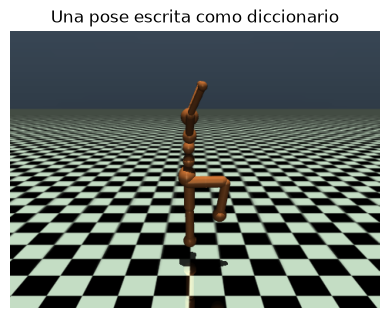

In [45]:
modelo, datos = taller.cargar("humanoide")
pose = {"right_hip_y": -90, "right_knee": -100, "right_shoulder1": -85,
        "left_shoulder1": 85, "right_elbow": -90, "left_elbow": -90}

for articulacion, grados in pose.items():
    taller.poner_angulo(modelo, datos, articulacion, grados)
taller.foto(modelo, datos, titulo="Una pose escrita como diccionario");

Y ahora con **física**: un diccionario de **órdenes a los motores** (motor → valor entre −1 y 1, NB03). La función `control` lo
traduce a `datos.ctrl` usando el listín `motor_id`, así que da igual en qué orden estén los motores por dentro. Ordenamos a las dos
caderas y las dos rodillas que se doblen al máximo:


In [46]:
modelo, datos = taller.cargar("humanoide")
ordenes = {"right_hip_y": -1, "left_hip_y": -1, "right_knee": -1, "left_knee": -1}

def control(modelo, datos):
    for motor, valor in ordenes.items():
        datos.ctrl[motor_id[motor]] = valor

taller.video(modelo, datos, segundos=2, control=control, nombre="nb21_ovillo");

El humanoide se hace un **ovillo** y se queda en el suelo. ¿Dónde ha quedado cada pieza? Un último diccionario, pieza → altura (la
altura es el tercer número de `datos.xpos`, la posición de cada pieza; la pieza 0 es el mundo y la saltamos):


In [47]:
altura = {modelo.body(i).name: datos.xpos[i][2] for i in range(1, modelo.nbody)}

for pieza in sorted(altura, key=altura.get, reverse=True)[:3]:
    print(f"{pieza:>15}: {altura[pieza]:.2f} m")
print("La más baja:", min(altura, key=altura.get))

         lwaist: 0.34 m
          torso: 0.29 m
right_upper_arm: 0.26 m
La más baja: right_shin


Lo más alto del ovillo es la cintura (`lwaist`, a **0,34 m**) y el torso (**0,29 m**); lo más bajo, las **espinillas** (`shin`), a 5 cm
del suelo: está de rodillas, hecho una bola.

### Tus retos

**Reto 1.** Haz el listín de las **piezas** (bodies), nombre → número, con una comprensión. ¿Qué número tiene `"left_foot"`? Compruébalo con
`mujoco.mj_name2id` y el tipo `mujoco.mjtObj.mjOBJ_BODY`.

**Reto 2.** Con una comprensión con `if`, fabrica la lista de articulaciones cuyo nombre contenga `"left"` (pista: `in`, NB20). ¿Cuántas son?

**Reto 3.** Con los diccionarios `topes` y `pose`, escribe un bucle que avise si algún ángulo de la pose se sale de los topes. Prueba
añadiendo a la pose `"left_knee": 30` (una rodilla doblada hacia delante).

**Reto 4.** Cambia el diccionario `ordenes` para que el humanoide **levante los brazos** (hombros `"right_shoulder1"` y `"left_shoulder1"`)
en vez de doblar las piernas. ¿Qué valor les das a cada uno? (Pista: mira sus topes en el Paso 4: no son simétricos.)

<details>
<summary>▶ Solución Reto 1</summary>

```python
pieza_id = {modelo.body(i).name: i for i in range(modelo.nbody)}
print(pieza_id["left_foot"])                                               # 9
print(mujoco.mj_name2id(modelo, mujoco.mjtObj.mjOBJ_BODY, "left_foot"))   # 9
```

Las piezas son 14: `world` (0), `torso` (1), `lwaist`, `pelvis`, muslos, espinillas, pies y brazos. El pie izquierdo es la **9**.
</details>

<details>
<summary>▶ Solución Reto 2</summary>

```python
izquierdas = [n for n in nombres if "left" in n]
print(izquierdas, len(izquierdas))
```

Son **7**: `left_hip_x`, `left_hip_z`, `left_hip_y`, `left_knee`, `left_shoulder1`, `left_shoulder2` y `left_elbow`. (Y otras 7 `right`:
el humanoide es simétrico.)
</details>

<details>
<summary>▶ Solución Reto 3</summary>

```python
pose["left_knee"] = 30
for articulacion, grados in pose.items():
    minimo, maximo = topes[articulacion]
    if not (minimo <= grados <= maximo):
        print(f"¡{articulacion} a {grados}° se sale de [{minimo:.0f}, {maximo:.0f}]!")
```

Avisa de `left_knee`: 30 grados se sale de [−160, −2]. (Es lo mismo que hace `taller.poner_angulo` por dentro cuando te avisa de los topes.)
</details>

<details>
<summary>▶ Solución Reto 4</summary>

En el Paso 4 viste que `right_shoulder1` va de −85 a 60 y `left_shoulder1` de −60 a 85: son **espejo** uno del otro. Para el mismo gesto
hay que darles órdenes de **signo contrario**, por ejemplo `ordenes = {"right_shoulder1": -1, "left_shoulder1": 1}`. Si les das el mismo
signo, un brazo sube y el otro baja. Moverlos por nombre no te libra de pensar en la geometría del robot, pero sí de equivocarte de motor.
</details>

### Qué has aprendido de MuJoCo hoy

- MuJoCo lo **numera todo**; tú trabajas con **nombres**. El puente: diccionarios nombre → número (`{modelo.joint(i).name: i ...}`) o la
  función **`mujoco.mj_name2id`** (que da −1 si el nombre no existe).
- `modelo.joint(i)`, `modelo.body(i)`, `modelo.actuator(i)` te dan cada articulación, pieza o motor; `.name` es su nombre.
- **Trampa 1:** la articulación libre `root` ocupa **7** números de `qpos`; por eso el número de una articulación no es su sitio en
  `qpos`. Usa **`modelo.jnt_qposadr`** (o `datos.joint(nombre).qpos`).
- **Trampa 2:** los **motores** no van en el mismo orden que las articulaciones. Da las órdenes **por nombre**.
- `modelo.jnt_range` (topes, en radianes), `modelo.actuator_gear` (fuerza de cada motor) y `datos.xpos` (posición de cada pieza) se
  ordenan y consultan de maravilla con diccionarios, `sorted(..., key=...)` y `max(..., key=...)`.

En la práctica del NB22 vas a **romper** MuJoCo a propósito: planos mal escritos, simulaciones que explotan y números que se vuelven
`nan`. Y aprenderás a atrapar esos errores con `try/except`.


## 15 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Ya sabes elegir y manejar la colección adecuada para cada cosa (en la práctica, hasta para orientarte dentro del humanoide de MuJoCo), y conoces la trampa del alias, que te ahorrará muchas horas de buscar errores. En el **NB22** vamos con el
**control del flujo** y los **errores**: el bucle `while`, `continue`, las **excepciones** (cómo provocar, capturar y manejar errores para que un entrenamiento de horas no se
caiga por un fallo tonto) y, sobre todo, cómo **depurar**: el arte de encontrar por qué un programa no hace lo que esperas.
